# Zone-wise CP-SAT — DP catalog

Same zone-wise CP-SAT as [`OneL-Zonewise-CPSAT-Handmade-Catalog.ipynb`](OneL-Zonewise-CPSAT-Handmade-Catalog.ipynb), but chains come from [`agent/dp_catalog.py`](../agent/dp_catalog.py) (`build_catalog`) instead of `handmade_dp_candidates.json`.

Layout from [`data/two_lands.md`](../data/two_lands.md) **LandOne** (zones I–V):

- **25 tiles** — 5×5 columns: farmer (I) + hire1–4 (II–V), **5 tiles per zone**
- **Ops caps** — farmer 18, hire1 17, hire2 16, hire3 14, hire4 13
- **Sequential cascade** — farmer → hire1 → hire2 → hire3 → hire4; shared cash + W/F
- **Money coupling (conservative)** — next zone opens at prev start − prev loss (setups + W/F buys + hire); sells excluded (timing unknown mid-day)
- **DP lags** — `DP_LAGS` passed into `build_catalog(..., lags=...)` (default `(0, 1, 2)`)
- **Per-hand hire cost** — fib terms $1 / $1 / $2 / $3 per day (total $7 when all four hired)
- **Glut caps** — rolling windows; harvest from prior zones locked, each zone fills remainder

## Results:
- Handmade > 91k
- (-1,0,1,2) > 75k
- (0,1,2) ~ 75k
- (0,1) > 67k
- (0,) < 40k


In [1]:
import json
import time

from ortools.sat.python import cp_model


In [2]:
import resource
import tracemalloc
from functools import wraps


def peak_mem(fn):
    @wraps(fn)
    def wrapper(*args, **kwargs):
        rss_before = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        tracemalloc.start()
        try:
            return fn(*args, **kwargs)
        finally:
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            rss_after = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            print(
                f"{fn.__name__}: tracemalloc peak={peak / 1e6:.1f} MB, "
                f"RSS max={rss_after / 1024:.1f} MB (was {rss_before / 1024:.1f} MB)"
            )

    return wrapper


In [3]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from agent.dp_catalog import build_catalog

with open("../data/crop_rollouts.json", "r") as f:
    crops_data = json.load(f)
# with open("../data/animal_rollouts.json", "r") as f:
with open("../data/animal_with_pickups.json", "r") as f:
    animals_data = json.load(f)


In [4]:
NUM_DAYS = 30
NUM_TILES = 25
BUILD_DAY_OFFSET = animals_data["meta"].get("build_day_offset", -1)
WHEAT_PRICE = 25
FERT_PRICE = 100
MAX_BUY = NUM_TILES * NUM_DAYS
STARTING_MONEY = 3000
DP_LAGS = (0,)  # passed to build_catalog(..., lags=DP_LAGS)

# FIVE layout — data/two_lands.md LandOne (zones I–V, 5 tiles each)
# Tile grid (1-indexed in spec): col V=21-25 ... col I=1-5 (farmer)
WORKERS = ("farmer", "hire1", "hire2", "hire3", "hire4")
HAND_WORKERS = ("hire1", "hire2", "hire3", "hire4")
HAND_DAILY_COST = {"hire1": 1, "hire2": 1, "hire3": 2, "hire4": 3}  # fib hand slots
HIRE_DAILY_COST = sum(HAND_DAILY_COST.values())  # 7/day when all four hired

WORKER_TILES = {
    "farmer": list(range(0, 5)),      # tiles 1–5  (zone I)
    "hire1": list(range(5, 10)),      # tiles 6–10 (zone II)
    "hire2": list(range(10, 15)),    # tiles 11–15 (zone III)
    "hire3": list(range(15, 20)),    # tiles 16–20 (zone IV)
    "hire4": list(range(20, 25)),    # tiles 21–25 (zone V)
}
NET_TILE_OPS = {
    "farmer": 18,
    "hire1": 17,
    "hire2": 16,
    "hire3": 14,
    "hire4": 13,
}

TILE_WORKER = (
    ["farmer"] * len(WORKER_TILES["farmer"])
    + ["hire1"] * len(WORKER_TILES["hire1"])
    + ["hire2"] * len(WORKER_TILES["hire2"])
    + ["hire3"] * len(WORKER_TILES["hire3"])
    + ["hire4"] * len(WORKER_TILES["hire4"])
)

PROFILE_SUFFIXES = ("no_fert", "with_fert", "no_care", "with_care")
GLUT_CAPS = {
    "MELON": {"window": 12, "cap": 52},
    "STRAWBERRY": {"window": 18, "cap": 20},
    "MILK": {"window": 3, "cap": 25},
    "WOOL": {"window": 4, "cap": 19},
}
GLUT_PRODUCTS = tuple(GLUT_CAPS)

ZERO_DAILY = {
    "daily_tile_ops": [0] * NUM_DAYS,
    "daily_wheat_pickup": [0] * NUM_DAYS,
    "daily_animal_place": [0] * NUM_DAYS,
    "daily_animal_active": [0] * NUM_DAYS,
    "daily_fert_pickup": [0] * NUM_DAYS,
    "daily_feed": [0] * NUM_DAYS,
    "daily_fert": [0] * NUM_DAYS,
    "daily_collect": [0] * NUM_DAYS,
    "daily_wheat": [0] * NUM_DAYS,
}


def i0_prices():
    prices = {crop: spec["base_price"] for crop, spec in crops_data["crops"].items()}
    for spec in animals_data["animals"].values():
        prices[spec["product"]] = spec["base_price"]
    return prices


I0 = i0_prices()


def price_of(product: str) -> int:
    return int(I0.get(product, 0))


def worker_for_tile(tile: int) -> str:
    return TILE_WORKER[tile]


def parse_profile_key(profile_key: str):
    for suffix in PROFILE_SUFFIXES:
        token = f"_{suffix}"
        if profile_key.endswith(token):
            return profile_key[: -len(token)], suffix
    raise ValueError(f"unknown profile key: {profile_key}")


def rollout_spec(label: str, profile_name: str):
    if label in crops_data["crops"]:
        spec = crops_data["crops"][label]
        return "crop", spec, spec[profile_name]
    if label in animals_data["animals"]:
        spec = animals_data["animals"][label]
        return "animal", spec, spec[profile_name]
    raise KeyError(label)


def parse_age_maps(profile, label, kind):
    harvest_map = dict(zip(profile["harvest_ages"], profile["yield_per_harvest"]))
    feed_by_age = {}
    fert_use_by_age = {}
    collect_by_age = {}
    wheat_gain_by_age = {}
    for day in profile["days"]:
        age = day["age"]
        acts = day["actions"]
        feed_by_age[age] = 1 if "FEED" in acts else 0
        fert_use_by_age[age] = 1 if "FERTILIZE" in acts else 0
        collect_by_age[age] = 1 if "COLLECT_FERTILIZER" in acts else 0
        if kind == "crop" and label == "WHEAT" and age in harvest_map:
            wheat_gain_by_age[age] = harvest_map[age]
        else:
            wheat_gain_by_age[age] = 0
    return feed_by_age, fert_use_by_age, collect_by_age, wheat_gain_by_age


def build_cash_by_day(start_day, setup_cost, base_price, profile):
    cash = [0] * NUM_DAYS
    spend = [0] * NUM_DAYS
    cash[start_day] -= setup_cost
    spend[start_day] -= setup_cost
    for age, yld in zip(profile["harvest_ages"], profile["yield_per_harvest"]):
        hday = start_day + age
        if hday < NUM_DAYS:
            cash[hday] += yld * base_price
    return cash, spend


def empty_daily_harvest():
    return {p: [0] * NUM_DAYS for p in GLUT_PRODUCTS}


def harvest_product(label: str, kind: str) -> str:
    if kind == "animal":
        return animals_data["animals"][label]["product"]
    return label


def add_daily(dst, src):
    for i in range(NUM_DAYS):
        dst[i] += src[i]


def stamp_placement(profile_key: str, start_day: int):
    label, profile_name = parse_profile_key(profile_key)
    kind, spec, profile = rollout_spec(label, profile_name)
    setup_cost = spec["seed_cost"] if kind == "crop" else spec["animal_cost"]
    base_price = spec["base_price"]
    feed_by_age, fert_use_by_age, collect_by_age, wheat_gain_by_age = parse_age_maps(
        profile, label, kind
    )

    daily_tile_ops = [0] * NUM_DAYS
    daily_wheat_pickup = [0] * NUM_DAYS
    daily_animal_place = [0] * NUM_DAYS
    daily_animal_active = [0] * NUM_DAYS
    daily_fert_pickup = [0] * NUM_DAYS
    daily_feed = [0] * NUM_DAYS
    daily_fert = [0] * NUM_DAYS
    daily_collect = [0] * NUM_DAYS
    daily_wheat = [0] * NUM_DAYS
    occupied = []

    if kind == "crop":
        for day in profile["days"]:
            cal = start_day + day["age"]
            if cal >= NUM_DAYS:
                return None
            occupied.append(cal)
            acts = day["actions"]
            daily_tile_ops[cal] += len(acts)
            if "FERTILIZE" in acts:
                daily_fert_pickup[cal] += 1
            age = day["age"]
            daily_feed[cal] += feed_by_age.get(age, 0)
            daily_fert[cal] += fert_use_by_age.get(age, 0)
            daily_collect[cal] += collect_by_age.get(age, 0)
            daily_wheat[cal] += wheat_gain_by_age.get(age, 0)
    else:
        for day in profile["days"]:
            cal = start_day + day["age"]
            if cal >= NUM_DAYS:
                break
            occupied.append(cal)
            acts = day["actions"]
            age = day["age"]
            daily_tile_ops[cal] += len(acts)
            if "FEED" in acts:
                daily_wheat_pickup[cal] += 1
            if age == 0:
                daily_animal_place[cal] = 1
            daily_animal_active[cal] = 1
            daily_feed[cal] += feed_by_age.get(age, 0)
            daily_fert[cal] += fert_use_by_age.get(age, 0)
            daily_collect[cal] += collect_by_age.get(age, 0)
            daily_wheat[cal] += wheat_gain_by_age.get(age, 0)
        if not occupied:
            return None
        build_day = start_day + BUILD_DAY_OFFSET
        if build_day < 0:
            build_day = start_day
        if build_day < NUM_DAYS:
            daily_tile_ops[build_day] += 1

    daily_harvest = empty_daily_harvest()
    for age, yld in zip(profile["harvest_ages"], profile["yield_per_harvest"]):
        d = start_day + age
        if d < NUM_DAYS:
            product = harvest_product(label, kind)
            if product in daily_harvest:
                daily_harvest[product][d] += yld

    cash, spend = build_cash_by_day(start_day, setup_cost, base_price, profile)
    rev = sum(
        yld * base_price
        for age, yld in zip(profile["harvest_ages"], profile["yield_per_harvest"])
        if start_day + age < NUM_DAYS
    )
    segment = {
        "kind": kind,
        "label": label,
        "profile": profile_name,
        "profile_key": profile_key,
        "start_day": start_day,
        "end_day": max(occupied) + 1,
    }
    return {
        "weight": rev - setup_cost,
        "cash_by_day": cash,
        "spend_by_day": spend,
        "segment": segment,
        "daily_tile_ops": daily_tile_ops,
        "daily_wheat_pickup": daily_wheat_pickup,
        "daily_animal_place": daily_animal_place,
        "daily_animal_active": daily_animal_active,
        "daily_fert_pickup": daily_fert_pickup,
        "daily_feed": daily_feed,
        "daily_fert": daily_fert,
        "daily_collect": daily_collect,
        "daily_wheat": daily_wheat,
        "daily_harvest": daily_harvest,
    }


def stamp_chain(chain, chain_idx):
    out = {k: v[:] for k, v in ZERO_DAILY.items()}
    cash_by_day = [0] * NUM_DAYS
    spend_by_day = [0] * NUM_DAYS
    skipped = []
    segments = []
    placements = []
    daily_harvest = empty_daily_harvest()

    for profile_key, start_day in chain:
        seg = stamp_placement(profile_key, start_day)
        if seg is None:
            skipped.append((profile_key, start_day))
            continue
        for key in ZERO_DAILY:
            add_daily(out[key], seg[key])
        add_daily(cash_by_day, seg["cash_by_day"])
        add_daily(spend_by_day, seg["spend_by_day"])
        for p in GLUT_PRODUCTS:
            add_daily(daily_harvest[p], seg["daily_harvest"][p])
        segments.append(seg["segment"])
        end_day = seg["segment"]["end_day"] - 1
        placements.append((profile_key, start_day, end_day))

    return {
        "id": f"C{chain_idx}" if chain else "IDLE",
        "chain_idx": chain_idx,
        "raw_chain": chain,
        "weight": sum(cash_by_day),
        "cash_by_day": cash_by_day,
        "spend_by_day": spend_by_day,
        **out,
        "segments": segments,
        "placements": placements,
        "skipped": skipped,
        "daily_harvest": daily_harvest,
    }


dp_raw = build_catalog(NUM_DAYS, price_of, lags=DP_LAGS)
chains = [stamp_chain(chain, i) for i, chain in enumerate(dp_raw)]

bad = [c for c in chains if c["skipped"]]
n_idle = sum(1 for c in chains if not c["raw_chain"])
print(f"{len(dp_raw) - n_idle} DP + {n_idle} idle -> {len(chains)} catalog entries (lags={DP_LAGS})")
if bad:
    print(f"chains with dropped placements: {len(bad)}")
    for c in bad[:5]:
        print(f"  {c['id']}: skipped {c['skipped']}")


24 DP + 1 idle -> 25 catalog entries (lags=(0,))


In [5]:
def solve_zone(
    worker: str,
    chains,
    *,
    opening_balances: list[int],
    w_open: int,
    f_open: int,
    locked_harvest: dict[str, list[int]],
    max_time: float = 30.0,
):
    """Single-zone CP-SAT with shared cash / W / F cascade inputs."""
    zsize = len(WORKER_TILES[worker])
    model = cp_model.CpModel()
    count = [model.NewIntVar(0, zsize, f"n_{worker}_{c['id']}") for c in chains]
    model.Add(sum(count) == zsize)

    cap = NET_TILE_OPS[worker]
    for day in range(NUM_DAYS):
        terms = []
        for ci, chain in enumerate(chains):
            var = count[ci]
            for key in (
                "daily_tile_ops",
                "daily_wheat_pickup",
                "daily_animal_place",
                "daily_fert_pickup",
            ):
                n = chain[key][day]
                if n:
                    terms.append(var * n)
        if worker in HAND_WORKERS:
            animal_terms = [
                count[ci]
                for ci, chain in enumerate(chains)
                if chain["daily_animal_active"][day]
            ]
            if animal_terms:
                preamble = model.NewBoolVar(f"preamble_{worker}_{day}")
                animal_count = sum(animal_terms)
                model.Add(preamble <= animal_count)
                model.Add(animal_count <= preamble * zsize)
                terms.append(preamble)
        if terms:
            model.Add(sum(terms) <= cap)

    buy_w, buy_f, buy_w_cost, buy_f_cost = [], [], [], []
    W = [model.NewIntVar(0, MAX_BUY, f"W_{worker}_{d}") for d in range(NUM_DAYS + 1)]
    F = [model.NewIntVar(0, MAX_BUY, f"F_{worker}_{d}") for d in range(NUM_DAYS + 1)]
    model.Add(W[0] == w_open)
    model.Add(F[0] == f_open)

    for d in range(NUM_DAYS):
        feed_d = sum(count[ci] * chains[ci]["daily_feed"][d] for ci in range(len(chains)))
        fert_d = sum(count[ci] * chains[ci]["daily_fert"][d] for ci in range(len(chains)))
        collect_d = sum(count[ci] * chains[ci]["daily_collect"][d] for ci in range(len(chains)))
        wheat_d = sum(count[ci] * chains[ci]["daily_wheat"][d] for ci in range(len(chains)))
        bw = model.NewIntVar(0, MAX_BUY, f"buy_w_{worker}_{d}")
        bf = model.NewIntVar(0, MAX_BUY, f"buy_f_{worker}_{d}")
        buy_w.append(bw)
        buy_f.append(bf)
        buy_w_cost.append(WHEAT_PRICE * bw)
        buy_f_cost.append(FERT_PRICE * bf)
        model.Add(W[d] >= feed_d)
        model.Add(F[d] >= fert_d)
        model.Add(W[d + 1] == W[d] - feed_d + wheat_d + bw)
        model.Add(F[d + 1] == F[d] - fert_d + collect_d + bf)

    balance_vars = []
    conservative_vars = []
    for d in range(NUM_DAYS):
        day_terms = [
            count[ci] * chains[ci]["cash_by_day"][d]
            for ci in range(len(chains))
            if chains[ci]["cash_by_day"][d]
        ]
        day_terms.append(-WHEAT_PRICE * buy_w[d])
        day_terms.append(-FERT_PRICE * buy_f[d])
        if worker in HAND_WORKERS:
            day_terms.append(-HAND_DAILY_COST[worker])
        spend_terms = [
            count[ci] * chains[ci]["spend_by_day"][d]
            for ci in range(len(chains))
            if chains[ci]["spend_by_day"][d]
        ]
        spend_terms.append(-WHEAT_PRICE * buy_w[d])
        spend_terms.append(-FERT_PRICE * buy_f[d])
        if worker in HAND_WORKERS:
            spend_terms.append(-HAND_DAILY_COST[worker])
        if worker in HAND_WORKERS:
            prev = opening_balances[d] if d < len(opening_balances) else opening_balances[-1]
        elif d == 0:
            prev = opening_balances[0]
        else:
            prev = opening_balances[d] + (balance_vars[d - 1] - opening_balances[0])
        bal = model.NewIntVar(0, 200_000, f"balance_{worker}_{d}")
        model.Add(bal == prev + (sum(day_terms) if day_terms else 0))
        balance_vars.append(bal)
        # Conservative handoff: start − loss (no sells); farmer chains on cons, not bal
        if worker in HAND_WORKERS:
            start_d = prev
        elif d == 0:
            start_d = opening_balances[0]
        else:
            start_d = opening_balances[d] + (conservative_vars[d - 1] - opening_balances[0])
        cons = model.NewIntVar(-200_000, 200_000, f"cons_{worker}_{d}")
        model.Add(cons == start_d + (sum(spend_terms) if spend_terms else 0))
        conservative_vars.append(cons)

    # GLUT OFF — A/B test (agent planner has no glut caps in _solve_zone)
    # for product, spec in GLUT_CAPS.items():
    #     window = spec["window"]
    #     cap = spec["cap"]
    #     locked = locked_harvest[product]
    #     for d_start in range(NUM_DAYS - window + 1):
    #         locked_sum = sum(locked[d] for d in range(d_start, d_start + window))
    #         terms = []
    #         for ci, chain in enumerate(chains):
    #             vec = chain["daily_harvest"][product]
    #             window_yield = sum(vec[d] for d in range(d_start, d_start + window))
    #             if window_yield:
    #                 terms.append(count[ci] * window_yield)
    #         if terms:
    #             model.Add(locked_sum + sum(terms) <= cap)

    obj_terms = [chains[ci]["weight"] * count[ci] for ci in range(len(chains))]
    obj_terms.extend(-c for c in buy_w_cost)
    obj_terms.extend(-c for c in buy_f_cost)
    model.Maximize(sum(obj_terms))

    solver = cp_model.CpSolver()
    solver.parameters.num_workers = 8
    solver.parameters.max_time_in_seconds = max_time
    t0 = time.perf_counter()
    status = solver.Solve(model)
    elapsed = time.perf_counter() - t0

    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return None

    w_levels = [int(solver.Value(W[d])) for d in range(NUM_DAYS + 1)]
    f_levels = [int(solver.Value(F[d])) for d in range(NUM_DAYS + 1)]
    closing = [int(solver.Value(b)) for b in balance_vars]
    conservative = [int(solver.Value(c)) for c in conservative_vars]
    zone_harvest = empty_daily_harvest()
    counts = {}
    for ci, chain in enumerate(chains):
        n = int(solver.Value(count[ci]))
        counts[ci] = n
        for _ in range(n):
            for p in GLUT_PRODUCTS:
                add_daily(zone_harvest[p], chain["daily_harvest"][p])

    return {
        "worker": worker,
        "status": solver.StatusName(status),
        "obj": solver.ObjectiveValue(),
        "elapsed": elapsed,
        "closing": closing,
        "conservative": conservative,
        "w_levels": w_levels,
        "f_levels": f_levels,
        "counts": counts,
        "zone_harvest": zone_harvest,
        "solver": solver,
        "count": count,
    }


def solve_zones_sequential(chains, max_time_per_zone: float = 30.0):
    opening = [STARTING_MONEY] * NUM_DAYS
    w_levels = [0] * (NUM_DAYS + 1)
    f_levels = [0] * (NUM_DAYS + 1)
    locked_harvest = empty_daily_harvest()
    results = []

    for worker in WORKERS:
        w_open = w_levels[1] if worker != WORKERS[0] else 0
        f_open = f_levels[1] if worker != WORKERS[0] else 0
        res = solve_zone(
            worker,
            chains,
            opening_balances=opening,
            w_open=w_open,
            f_open=f_open,
            locked_harvest=locked_harvest,
            max_time=max_time_per_zone,
        )
        if res is None:
            print(f"zone={worker} INFEASIBLE")
            break
        print(
            f"zone={worker} {res['status']} obj={res['obj']:.0f} "
            f"time={res['elapsed']:.3f}s close0={res['closing'][0]} "
            f"cons0={res['conservative'][0]} "
            f"w1={res['w_levels'][1]} hire={HAND_DAILY_COST.get(worker, 0)}"
        )
        results.append(res)
        opening = res["conservative"]
        w_levels = res["w_levels"]
        f_levels = res["f_levels"]
        for p in GLUT_PRODUCTS:
            add_daily(locked_harvest[p], res["zone_harvest"][p])
    return results


In [6]:
MAX_TIME_PER_ZONE = 30.0

t0 = time.perf_counter()
zone_results = solve_zones_sequential(chains, max_time_per_zone=MAX_TIME_PER_ZONE)
total_elapsed = time.perf_counter() - t0

if not zone_results:
    raise RuntimeError("sequential solve failed")

sum_obj = sum(r["obj"] for r in zone_results)
hire_total = HIRE_DAILY_COST * NUM_DAYS
print()
print(f"zones solved: {len(zone_results)}/{len(WORKERS)}")
print(f"sum zone objectives: {sum_obj:.0f}")
print(f"total sequential time: {total_elapsed:.3f}s")
print(f"implied bank delta (sum obj - hires): {sum_obj - hire_total:.0f}")
print(f"implied ending bank: {STARTING_MONEY + sum_obj - hire_total:.0f}")
print(f"catalog: DP lags={DP_LAGS} ({len(chains)} chains)")


zone=farmer OPTIMAL obj=8505 time=0.014s close0=2660 cons0=2660 w1=0 hire=0
zone=hire1 OPTIMAL obj=8505 time=0.014s close0=2319 cons0=2319 w1=0 hire=1
zone=hire2 OPTIMAL obj=7740 time=0.012s close0=1998 cons0=1998 w1=0 hire=1
zone=hire3 OPTIMAL obj=7335 time=0.009s close0=1716 cons0=1716 w1=0 hire=2
zone=hire4 OPTIMAL obj=6570 time=0.011s close0=1453 cons0=1453 w1=0 hire=3

zones solved: 5/5
sum zone objectives: 38655
total sequential time: 0.095s
implied bank delta (sum obj - hires): 38445
implied ending bank: 41445
catalog: DP lags=(0,) (25 chains)


In [7]:
# Decode per-tile assignments from zone count solutions

selected = []
for res in zone_results:
    worker = res["worker"]
    remaining = list(WORKER_TILES[worker])
    for ci, chain in enumerate(chains):
        for _ in range(res["counts"].get(ci, 0)):
            tile = remaining.pop(0)
            selected.append({"tile": tile, "worker": worker, "chain": chain})
selected.sort(key=lambda row: row["tile"])

print(f"n tiles assigned: {len(selected)}")
for row in selected:
    tile = row["tile"]
    worker = row["worker"]
    chain = row["chain"]
    if chain["id"] == "IDLE" or not chain["raw_chain"]:
        print(f"  tile={tile:2d} {worker:6s} IDLE")
        continue
    body = ", ".join(f"{pk}@{sd}" for pk, sd in chain["raw_chain"])
    print(f"  tile={tile:2d} {worker:6s} {chain['id']:4s} weight={chain['weight']:.0f}  [{body}]")


n tiles assigned: 25
  tile= 0 farmer C1   weight=765  [CARROT_no_fert@0, CARROT_no_fert@3, CARROT_no_fert@6, CARROT_no_fert@9, CARROT_no_fert@12, CARROT_no_fert@15, CARROT_no_fert@18, CARROT_no_fert@21, CARROT_no_fert@24]
  tile= 1 farmer C15  weight=1935  [MELON_no_fert@0, WHEAT_no_fert@10, CARROT_no_fert@14, CARROT_no_fert@17, CARROT_no_fert@20, CARROT_no_fert@23, CARROT_no_fert@26]
  tile= 2 farmer C15  weight=1935  [MELON_no_fert@0, WHEAT_no_fert@10, CARROT_no_fert@14, CARROT_no_fert@17, CARROT_no_fert@20, CARROT_no_fert@23, CARROT_no_fert@26]
  tile= 3 farmer C15  weight=1935  [MELON_no_fert@0, WHEAT_no_fert@10, CARROT_no_fert@14, CARROT_no_fert@17, CARROT_no_fert@20, CARROT_no_fert@23, CARROT_no_fert@26]
  tile= 4 farmer C15  weight=1935  [MELON_no_fert@0, WHEAT_no_fert@10, CARROT_no_fert@14, CARROT_no_fert@17, CARROT_no_fert@20, CARROT_no_fert@23, CARROT_no_fert@26]
  tile= 5 hire1  C1   weight=765  [CARROT_no_fert@0, CARROT_no_fert@3, CARROT_no_fert@6, CARROT_no_fert@9, CARROT

In [8]:
# Glut season totals (locked + last zone)

season_harvest = empty_daily_harvest()
for res in zone_results:
    for p in GLUT_PRODUCTS:
        add_daily(season_harvest[p], res["zone_harvest"][p])

print("\nGlut cap check (season total vs cap):")
for product, spec in GLUT_CAPS.items():
    total = sum(season_harvest[product])
    cap = spec["cap"]
    flag = "BINDING" if total > cap else "ok"
    print(f"  {product:12s} cap={cap:3d} total={total:3d}  {flag}")



Glut cap check (season total vs cap):
  MELON        cap= 52 total=108  BINDING
  STRAWBERRY   cap= 20 total=  0  ok
  MILK         cap= 25 total=  0  ok
  WOOL         cap= 19 total=  0  ok


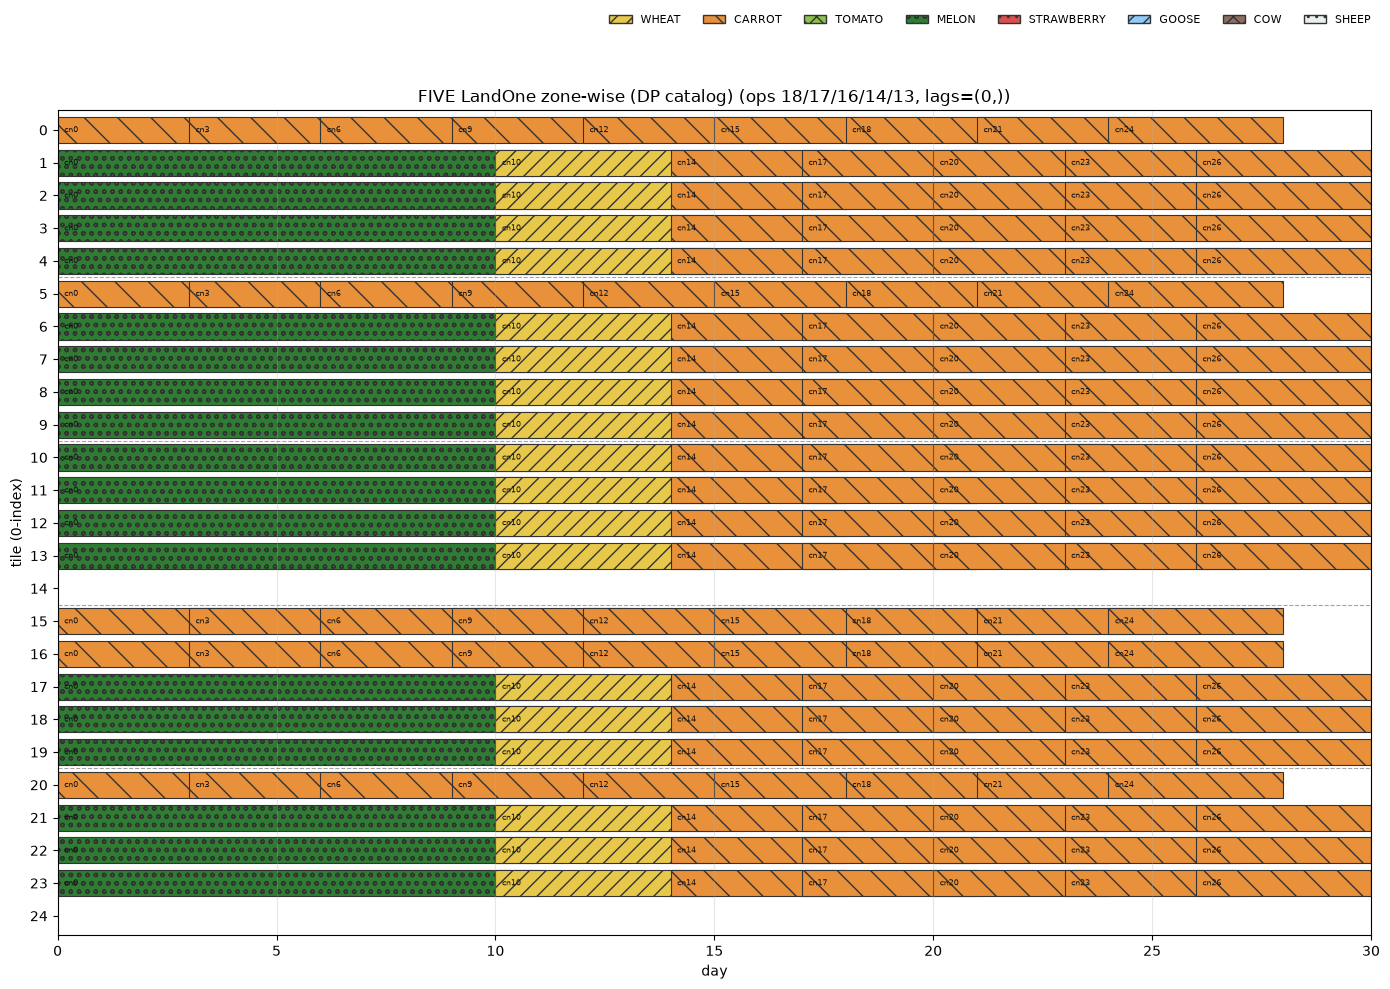

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

CROP_STYLE = {
    "WHEAT": {"color": "#e8c84a", "hatch": "//"},
    "CARROT": {"color": "#e8913a", "hatch": "\\"},
    "TOMATO": {"color": "#8bc34a", "hatch": "xx"},
    "MELON": {"color": "#2e7d32", "hatch": "oo"},
    "STRAWBERRY": {"color": "#d94f4f", "hatch": ".."},
}
ANIMAL_STYLE = {
    "GOOSE": {"color": "#90caf9", "hatch": "//"},
    "COW": {"color": "#8d6e63", "hatch": "xx"},
    "SHEEP": {"color": "#eceff1", "hatch": ".."},
}


def bar_style(segment):
    if segment["kind"] == "crop":
        st = dict(CROP_STYLE.get(segment["label"], {"color": "#999999", "hatch": ""}))
    else:
        st = dict(ANIMAL_STYLE.get(segment["label"], {"color": "#999999", "hatch": ""}))
    if segment["profile"] in ("with_fert", "with_care"):
        st["edgecolor"] = "#1565c0" if segment["kind"] == "crop" else "#c62828"
        st["linewidth"] = 1.5
    else:
        st.setdefault("edgecolor", "#333333")
        st.setdefault("linewidth", 0.8)
    return st


fig, ax = plt.subplots(figsize=(14, 10))
for row in selected:
    tile = row["tile"]
    chain = row["chain"]
    for seg in chain["segments"]:
        st = bar_style(seg)
        ax.barh(
            y=tile,
            width=seg["end_day"] - seg["start_day"],
            left=seg["start_day"],
            height=0.8,
            color=st["color"],
            hatch=st["hatch"],
            edgecolor=st["edgecolor"],
            linewidth=st["linewidth"],
        )
        tag = f"{seg['kind'][0]}{seg['profile'][0]}{seg['start_day']}"
        ax.text(seg["start_day"] + 0.15, tile, tag, va="center", fontsize=6, color="#111")

# Zone dividers: 5 tiles per zone (I–V)
for yline in (4.5, 9.5, 14.5, 19.5):
    ax.axhline(yline, color="#666666", linewidth=0.8, linestyle="--", alpha=0.6)

ax.set_xlabel("day")
ax.set_ylabel("tile (0-index)")
ax.set_yticks(range(NUM_TILES))
ax.set_xlim(0, NUM_DAYS)
ax.set_ylim(-0.6, NUM_TILES - 0.4)
ax.set_title(
    "FIVE LandOne zone-wise (DP catalog) "
    f"(ops {NET_TILE_OPS['farmer']}/"
    f"{NET_TILE_OPS['hire1']}/"
    f"{NET_TILE_OPS['hire2']}/"
    f"{NET_TILE_OPS['hire3']}/"
    f"{NET_TILE_OPS['hire4']}, lags={DP_LAGS})"
)
ax.invert_yaxis()
legend_handles = [
    Patch(facecolor=st["color"], hatch=st["hatch"], edgecolor="#333333", label=name)
    for name, st in {**CROP_STYLE, **ANIMAL_STYLE}.items()
]
ax.grid(axis="x", alpha=0.3)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
    bbox_transform=fig.transFigure,
    ncol=len(legend_handles),
    fontsize=8,
    frameon=False,
)
plt.show()